# Performance of Gradual Warping Set Descriptors with DTW as the Baseline


In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Import from local directory
import sys
sys.path.insert(0, '../src')
from TemporalGP.utils import compute_distance, gp_descriptor_spider_plot, gen_distance_plot
from TemporalGP.TGP.tgrad_ami import TGradAMI
# from TemporalGP.TGP.t_graank import TGrad

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



Configure TGradAMI algorithm hyperparameters.

In [2]:
# Hyperparameters

# f_path = "../datasets/air_quality1k.csv"
# f_path = "../datasets/air_quality25.csv"

f_path_evi = "../datasets/ke_evi_data_2k.csv"
f_path_rain = "../datasets/ke_rain_data_2k.csv"

eq = False
min_sup = 0.5
tgt_cols = [1, 2, 3, 4]
min_rep = 0.75
mi_err_margin = 0.0001
eval_mode = True
clustering_method = False

Visualize the top 5 rows of the dataset.

In [3]:
rain_data = pd.read_csv(f_path_rain)
evi_data = pd.read_csv(f_path_evi)


print(rain_data.head())
print("\n")
print(evi_data.head())

  Date (Jul-Sep)   NRB (mm)   KAK (mm)   MAK (mm)   WAJ (mm)
0        07-2000   22.01000   526.8000      18.45  12.219990
1        07-2001   57.55001   539.0801       0.90  13.440000
2        07-2002   45.17000   349.2700      20.47  15.320000
3        07-2003   77.08001   660.0199       2.27   8.940001
4        07-2004   16.48000   424.6999       0.71   4.819999


  Date (Jul-Sep)   NRB (EVI)   KAK (EVI)   MAK (EVI)   WAJ (EVI)
0        07-2000    0.094866    0.401556    0.160511    0.120766
1        07-2001    0.236884    0.417010    0.183184    0.152754
2        07-2002    0.243191    0.370047    0.206061    0.109228
3        07-2003    0.202896    0.423199    0.159602    0.109228
4        07-2004    0.119559    0.378931    0.178707    0.099040


Initialize TGradAMI algorithm by creating an object.

In [4]:
rain_tgrads = []
evi_tgrads = []
for t_col in tgt_cols:
    t_grad_rain = TGradAMI(f_path_rain, min_sup, eq, target_col=t_col, min_rep=min_rep, min_error=mi_err_margin)
    t_grad_evi = TGradAMI(f_path_evi, min_sup, eq, target_col=t_col, min_rep=min_rep, min_error=mi_err_margin)

    rain_tgrads.append(t_grad_rain)
    evi_tgrads.append(t_grad_evi)

Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok
Dataset Ok


Run the algorithm for mining FTGPs (Fuzzy Temporal Gradual Patterns) in evaluation mode. The algorithm returns a number of results in a dict format. The transformed dataset is also returned.

In [5]:
rain_tgrad_data = []
evi_tgrad_data = []
for i, t_grad_rain in enumerate(rain_tgrads):
    eval_dict_rain = t_grad_rain.discover_tgp(use_clustering=clustering_method, eval_mode=eval_mode)
    transform_steps = eval_dict_rain['Transformation Steps']
    eval_dict_evi = evi_tgrads[i].discover_tgp(use_clustering=clustering_method, transformation_steps=transform_steps, eval_mode=eval_mode)

    rain_tgrad_data.append(eval_dict_rain)
    evi_tgrad_data.append(eval_dict_evi)

In [6]:
trans_data_rain = rain_tgrad_data[0]['Transformed Data']
trans_data_evi = evi_tgrad_data[0]['Transformed Data']

# Put in a dataframe
rain_trans_df = pd.DataFrame(trans_data_rain[1:], columns=rain_tgrads[0].titles)
evi_trans_df = pd.DataFrame(trans_data_evi[1:], columns=evi_tgrads[0].titles)

print("Transformed Data:")
print(rain_trans_df.head())
print("\nEVI Data:")
print(evi_trans_df.head())


Transformed Data:
  Date (Jul-Sep)  NRB (mm)  KAK (mm)   MAK (mm)  WAJ (mm)
0        07-2000     22.01  539.0801   4.420001     13.44
1        07-2001  57.55001    349.27       6.75     15.32
2        07-2002     45.17  660.0199       1.51  8.940001
3        07-2003  77.08001  424.6999       1.29  4.819999
4        07-2004     16.48  327.3999  0.4299998     11.81

EVI Data:
  Date (Jul-Sep)   NRB (EVI)   KAK (EVI)   MAK (EVI)   WAJ (EVI)
0        07-2000  0.09486629  0.41701043  0.18705401  0.15275404
1        07-2001  0.23688364  0.37004653  0.19968794  0.10922809
2        07-2002  0.24319097   0.4231988  0.24569514  0.10922809
3        07-2003  0.20289575   0.3789313  0.18350513  0.09904013
4        07-2004  0.11955917   0.4205146   0.1951361  0.09919044


### Spider plot of GP Warping Set Descriptors

In [7]:
patterns = [t_grad_rain.display_patterns_as_df for t_grad_rain in rain_tgrads]  # Collect all patterns into a list
res_rain_df = pd.concat(patterns, ignore_index=True)  # Combine them in one go

categories = ['Support', 'Density', 'Avg. Deviation from Diagonal', 'Rank Dispersion', 'Graph Connectivity', 'Singularity Score']
numeric_rain_df = res_rain_df[categories].astype(float)
stats_rain = numeric_rain_df.agg(['mean', 'std'])

res_rain_df_w_stats = pd.concat([res_rain_df, stats_rain])
res_rain_df_w_stats

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (mm)+, (KAK (mm)-) +12.0 months",0.542,0.328,6.602,4.338,1,3.084
1,"NRB (mm)+, (MAK (mm)-) +5.0 years",0.549,0.332,5.917,3.668,1,3.386
2,"NRB (mm)+, (WAJ (mm)-) +12.0 months",0.608,0.368,6.538,4.411,1,3.182
3,"KAK (mm)-, (NRB (mm)+) +3.0 years",0.553,0.415,7.124,4.372,1,2.146
4,"KAK (mm)+, (MAK (mm)+) +3.0 years",0.542,0.407,7.068,4.712,1,2.403
5,"KAK (mm)+, (WAJ (mm)-) +2.0 years",0.537,0.403,7.0,4.632,1,3.072
6,"MAK (mm)-, (NRB (mm)+) +4.0 years",0.661,0.447,6.611,4.297,1,2.678
7,"MAK (mm)+, (KAK (mm)+) +3.0 years",0.591,0.399,7.059,4.387,1,3.277
8,"MAK (mm)+, (WAJ (mm)+) +2.0 years",0.55,0.372,6.904,4.245,1,3.028
9,"WAJ (mm)-, (NRB (mm)+) +3.0 years",0.716,0.538,6.904,4.449,1,2.152


In [8]:
patterns = [t_grad_evi.display_patterns_as_df for t_grad_evi in evi_tgrads]  # Collect all patterns into a list
res_evi_df = pd.concat(patterns, ignore_index=True)  # Combine them in one go

numeric_evi_df = res_evi_df[categories].astype(float)
stats_evi = numeric_evi_df.agg(['mean', 'std'])

res_evi_df_w_stats = pd.concat([res_evi_df, stats_evi])
res_evi_df_w_stats

,Pattern,Support,Density,Avg. Deviation from Diagonal,Rank Dispersion,Graph Connectivity,Singularity Score
0,"NRB (EVI)+, (KAK (EVI)-) +12.0 months",0.51,0.308,6.244,4.114,1,3.628
1,"NRB (EVI)+, (MAK (EVI)-) +5.0 years",0.523,0.316,6.125,3.779,1,3.131
2,"NRB (EVI)+, (WAJ (EVI)-) +12.0 months",0.575,0.348,6.989,4.174,1,2.689
3,"KAK (EVI)-, (NRB (EVI)+) +3.0 years",0.632,0.474,6.858,4.361,1,3.032
4,"KAK (EVI)+, (MAK (EVI)+) +3.0 years",0.553,0.415,6.181,3.949,1,2.555
5,"KAK (EVI)+, (WAJ (EVI)-) +2.0 years",0.584,0.439,7.243,4.746,1,3.114
6,"MAK (EVI)+, (NRB (EVI)+) +4.0 years",0.632,0.427,6.972,4.543,1,2.636
7,"MAK (EVI)-, (KAK (EVI)+) +3.0 years",0.515,0.348,7.034,4.466,1,3.302
8,"MAK (EVI)+, (WAJ (EVI)+) +2.0 years",0.684,0.462,6.735,4.365,1,2.997
9,"WAJ (EVI)+, (NRB (EVI)+) +3.0 years",0.526,0.395,7.09,4.434,1,2.124


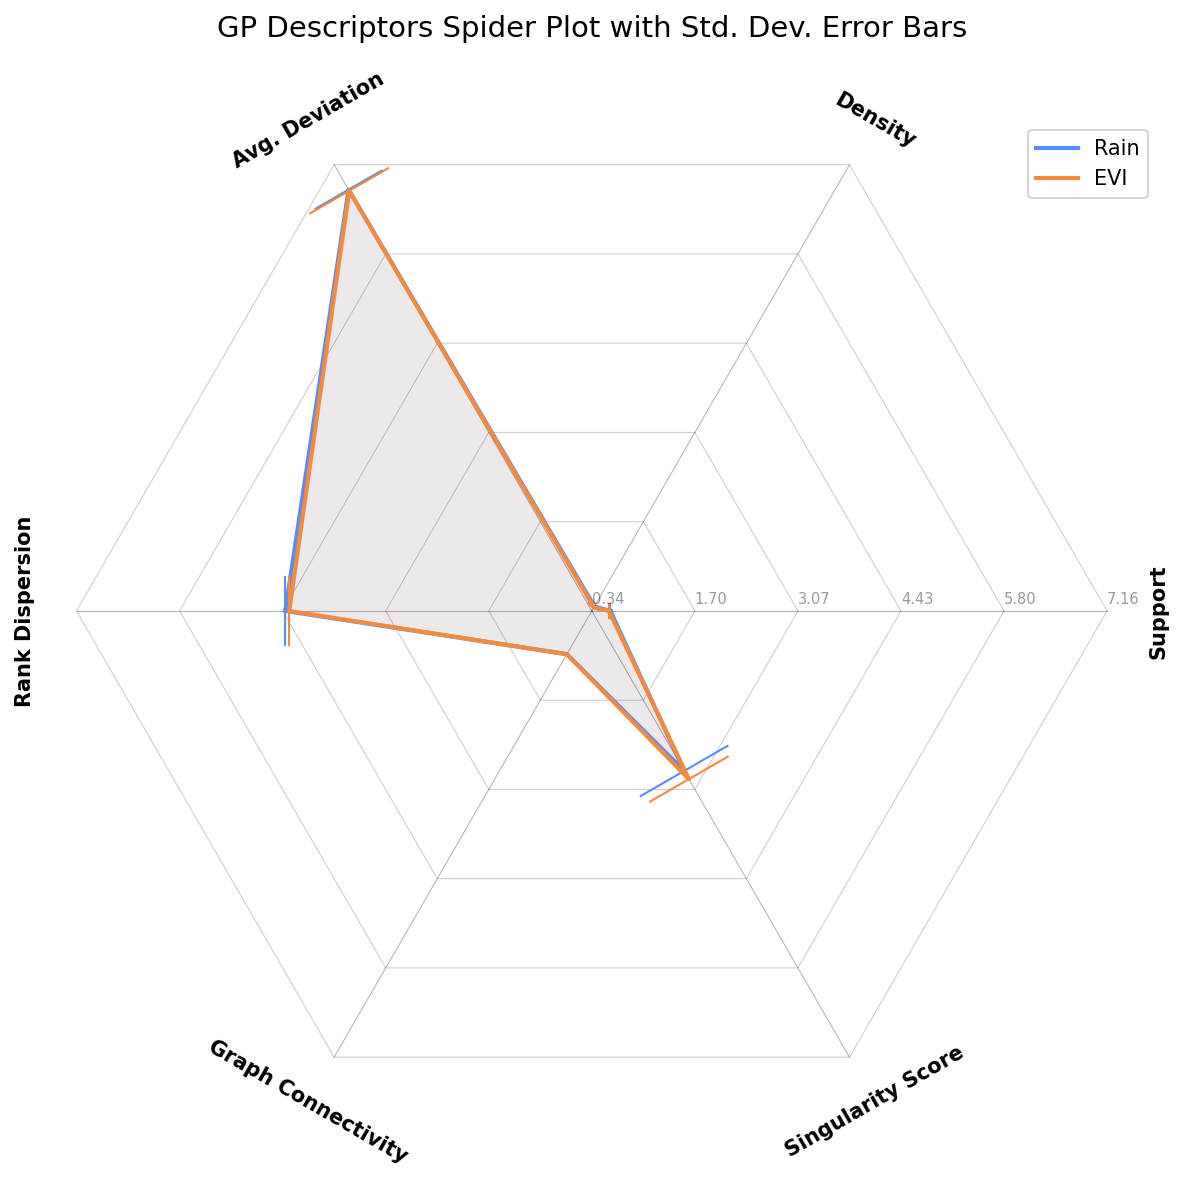

In [9]:
plt_fig = gp_descriptor_spider_plot([numeric_rain_df, numeric_evi_df], ['Rain', 'EVI'], categories)
#plt_fig.show()

### Comparing the Euclidean distance and DTW alignment distance
We compare the similarity between attribute data for the original and transformed datasets

In [10]:
dtw_data = []
euc_data = []
for i, tgrad in enumerate(rain_tgrads):
    orig_rain_data = tgrad.data
    orig_evi_data = evi_tgrads[i].data
    trans_data_rain = rain_tgrad_data[i]['Transformed Data']
    trans_data_evi = evi_tgrad_data[i]['Transformed Data']
    dtw_dict, euc_dict = compute_distance(tgrad, orig_rain_data, orig_evi_data, trans_data_rain, trans_data_evi)
    dtw_data.append(dtw_dict)
    euc_data.append(euc_dict)

In [11]:
print("DTW Distance Data:")
print(dtw_data)
print("\nEuclidean Distance Data:")
print(euc_data)

DTW Distance Data:
[{'Orig (NRB)': {'KAK (mm)': 1425.7108040199998, 'MAK (mm)': 1433.5001336799996, 'WAJ (mm)': 1436.7815759409996}, 'Transformed (NRB)': {'KAK (mm)': 1137.98359722, 'MAK (mm)': 1144.63891352, 'WAJ (mm)': 1146.703514911}}, {'Orig (KAK)': {'NRB (mm)': 16908.397940847, 'MAK (mm)': 16906.76942854, 'WAJ (mm)': 16909.782307141002}, 'Transformed (KAK)': {'NRB (mm)': 14616.782940052, 'MAK (mm)': 14615.312126379999, 'WAJ (mm)': 14618.071107351001}}, {'Orig (MAK)': {'NRB (mm)': 187.982030842, 'KAK (mm)': 178.08084932, 'WAJ (mm)': 189.15162124100004}, 'Transformed (MAK)': {'NRB (mm)': 175.22987502199996, 'KAK (mm)': 165.25651447999996, 'WAJ (mm)': 175.10936574099998}}, {'Orig (WAJ)': {'NRB (mm)': 301.38204254199997, 'KAK (mm)': 291.48086101999996, 'MAK (mm)': 299.2701906799999}, 'Transformed (WAJ)': {'NRB (mm)': 273.644569077, 'KAK (mm)': 264.16569495, 'MAK (mm)': 271.70527296}}]

Euclidean Distance Data:
[{'Orig (NRB)': {'KAK (mm)': 261.5735404231991, 'MAK (mm)': 262.42209641541

### Plot the DTW and Euclidean Distances

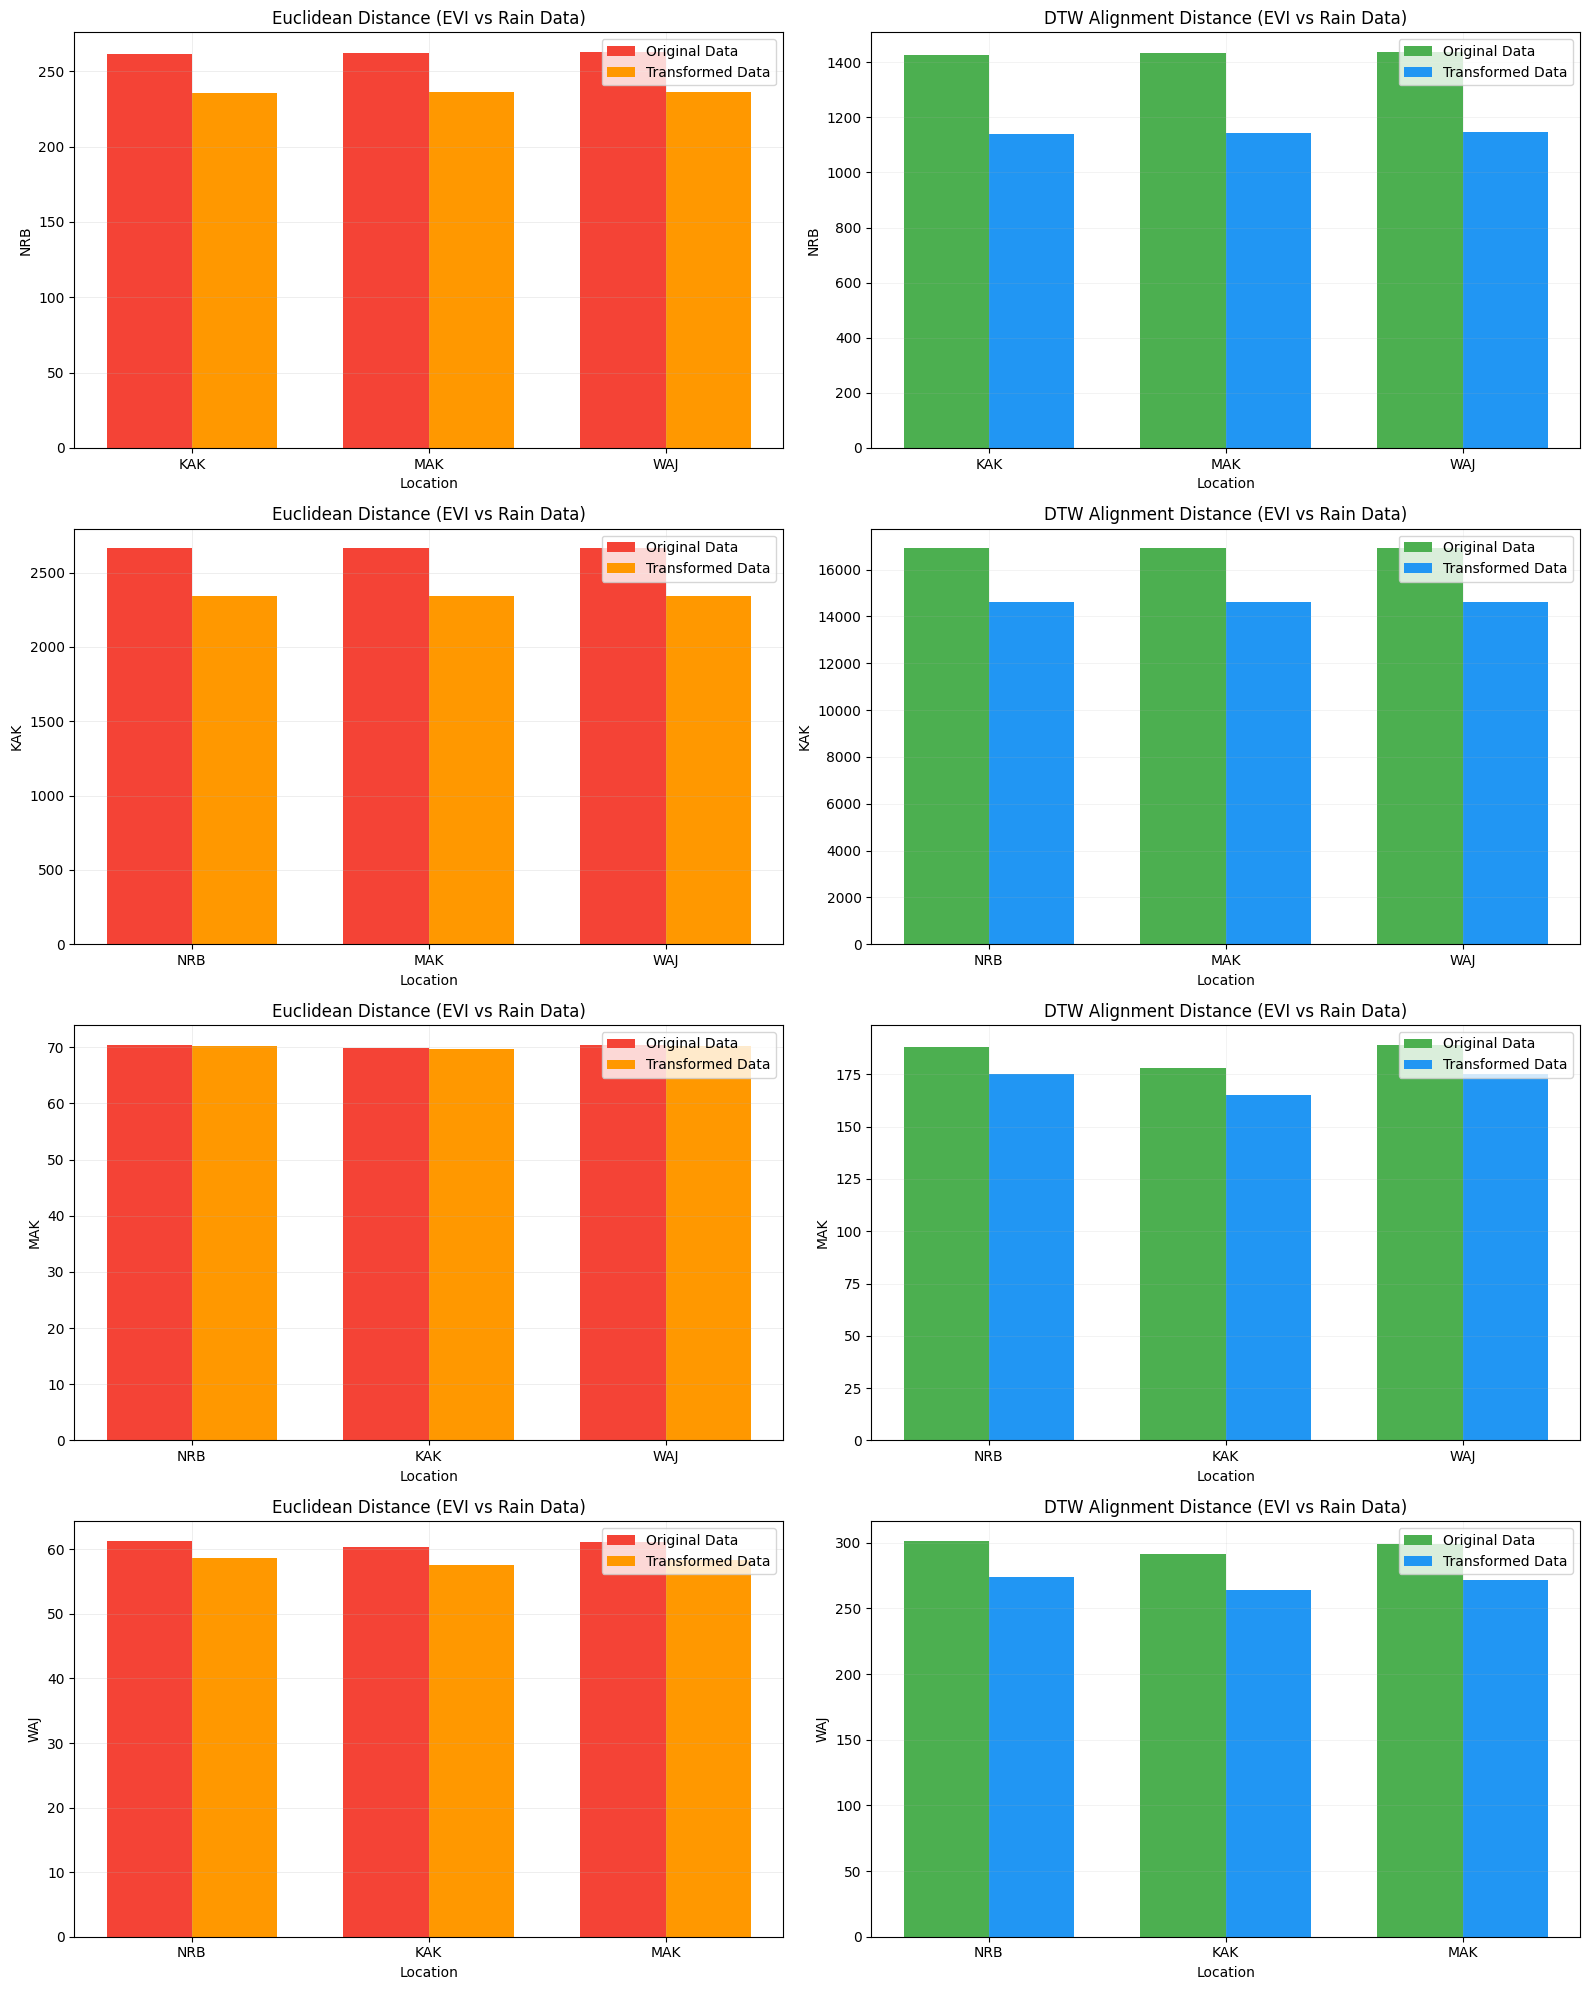

In [12]:
plt_fig2 = gen_distance_plot(rain_tgrads, dtw_data, euc_data)

## Multiple Timeseries Composition using FTGPs

We can use FTGPs to decompose the pairwise object pairs gradual items (GIs) or gradual patterns (GPs) (which are associated with specific attributes/timeseries) into a single scale *warping path* that will allow us to accurately measure the gradual similarity of different timeseries datasets.

* We can visualize the GIs or GPs as shown below.

In [13]:
## SO4GP Method for getting GP Warping Sets
rain_tgrads[0].fit_warpingset()
warping_set = rain_tgrads[0].warping_set

In [14]:
warping_set.keys()
#warping_set.items()

dict_keys(['1+', '1-', '2+', '2-', '3+', '3-', '4+', '4-'])

* We draw numerous plots to visualize the multiple timeseries decompositions using FTGPs. Timeseries data that have strong correlation will produce a decomposition graph with dense zigzag patterns. Those with weak correlation will produce a decomposition graph with sparse zigzag patterns.

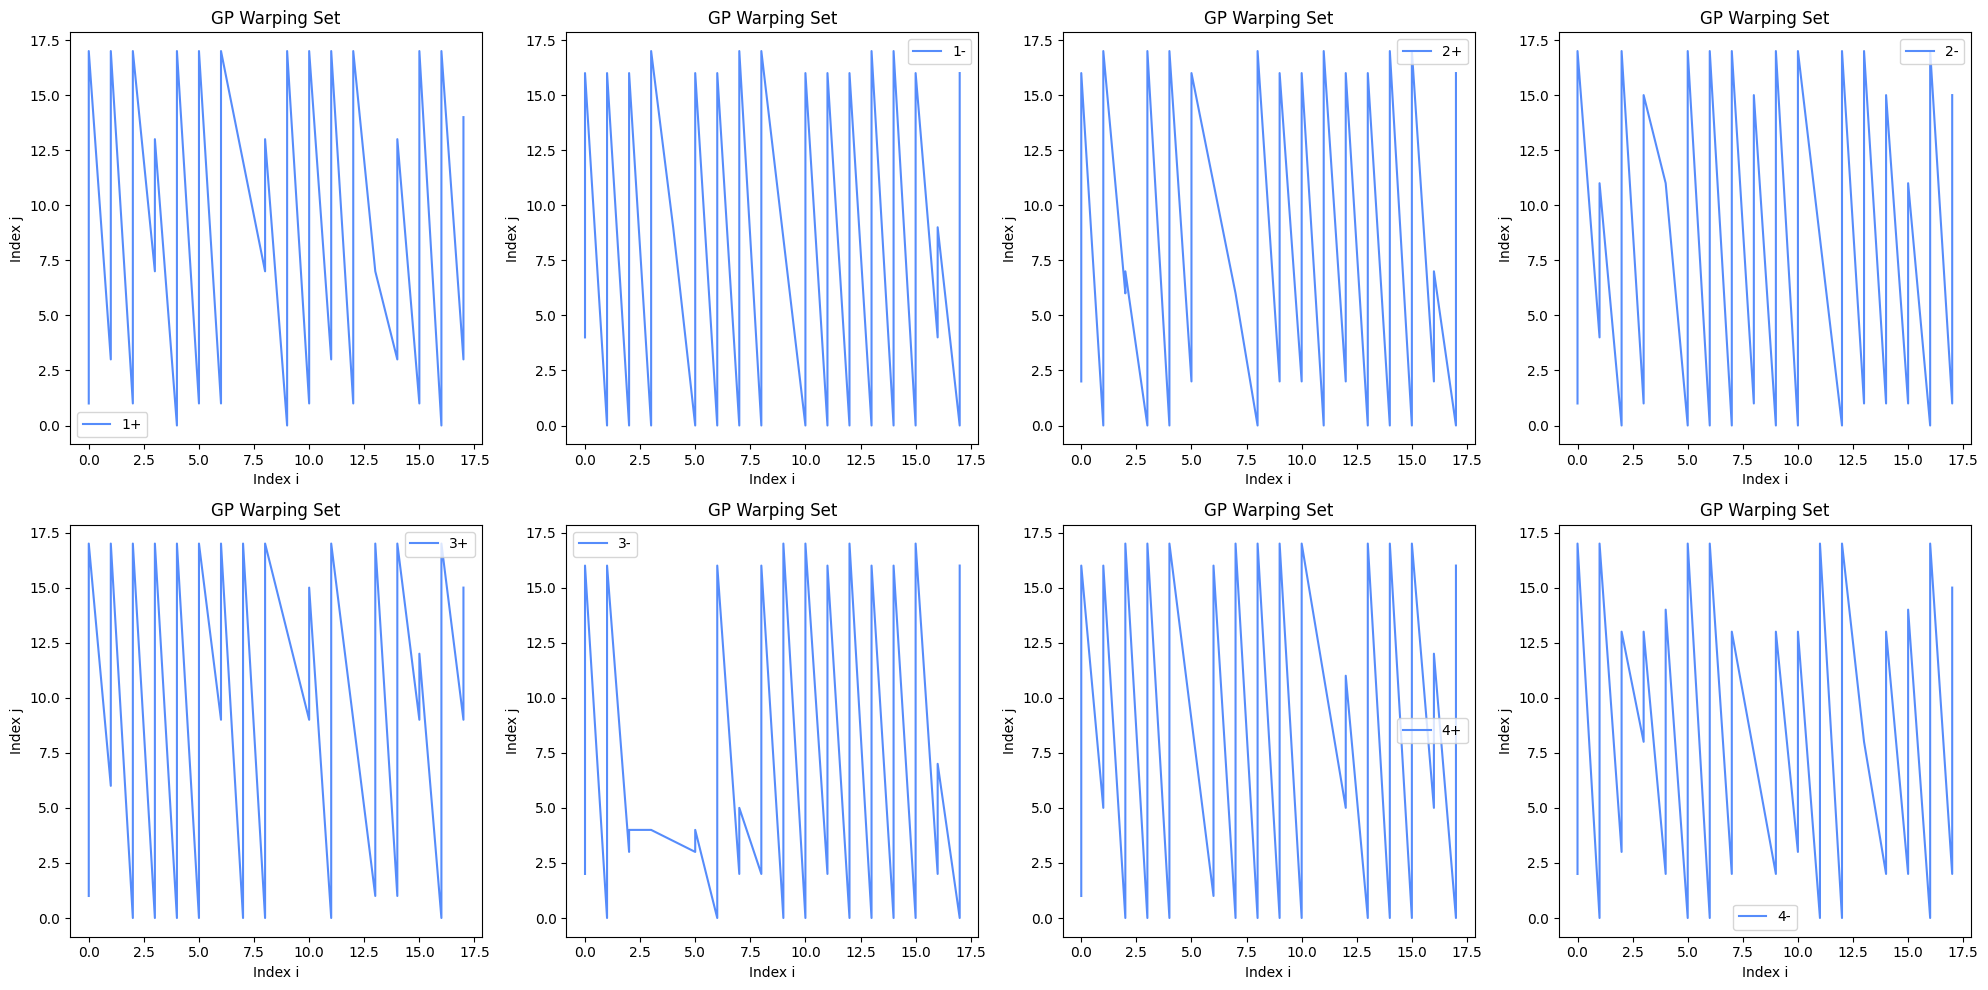

In [15]:
# Calculate the number of rows needed
num_plots = len(warping_set or {})
cols = 4
rows = math.ceil(num_plots / cols)

# Create subplots with the required number of rows and columns
fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 5))
axes = axes.flatten()  # Flatten to make indexing easier

# Plot each component in its subplot
for idx, (key, val) in enumerate(warping_set.items()):
    axes[idx].plot([p[0] for p in val], [p[1] for p in val], '-', label=f"{key}")
    axes[idx].set_xlabel("Index i")
    axes[idx].set_ylabel("Index j")
    axes[idx].legend()
    axes[idx].set_title(f"GP Warping Set")

# Hide any extra subplots
for ax in axes[num_plots:]:
    ax.axis("off")

plt.tight_layout()
plt.show()